# Recommendation systems EDA

## Importación de librerías y paquetes y definición de constantes

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings

In [146]:
warnings.filterwarnings("ignore")

## Recopilación de datos

In [147]:
df = pd.read_csv("../data/raw/adult-census-income.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Análisis descriptivo 

In [148]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [149]:
df['capital.loss'].value_counts()

capital.loss
0       31042
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2163        1
1944        1
1539        1
2472        1
Name: count, Length: 92, dtype: int64

In [150]:
df.shape

(32561, 15)

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [152]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [153]:
df.duplicated().sum()

24

### No hay duplicados pero nos aseguramos de borrarlos

In [154]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(32537, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [155]:
df.duplicated().sum()

0

### Valores nulos o faltantes:

In [156]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64

#### No hay valores nulos a primera vista, aunque observamos que existe falta de datos

In [157]:
df[df['workclass']== '?']

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [158]:
df[df['occupation']== '?']

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [159]:
df[(df['occupation']== '?')|(df['workclass']== '?')]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [160]:
df = df.replace('?', np.nan)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [161]:
df.isnull().sum().sort_values(ascending=False) / len(df)

occupation        0.056643
workclass         0.056428
native.country    0.017887
age               0.000000
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
income            0.000000
dtype: float64

### Convertimos los valores raros en nulos para poder contabilizarlos, aparentemente no representan un gran porcentaje, pero hay que tenerlo en cuenta

### Limpieza de datos: Eliminar información irrelevante

In [166]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_categoricas = [col for col in columnas_categoricas if col != df.select_dtypes(include=['int64', 'float64']).columns.tolist()]
encoders = {} 
for columna in columnas_categoricas:
    le = LabelEncoder()
    df[columna] = le.fit_transform(df[columna])
    encoders[columna] = le
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,3,310152,15,10,4,10,1,4,1,0,0,40,38,0
32557,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0
32558,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1
32559,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int32
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int32
 4   education.num   32537 non-null  int64
 5   marital.status  32537 non-null  int32
 6   occupation      32537 non-null  int32
 7   relationship    32537 non-null  int32
 8   race            32537 non-null  int32
 9   sex             32537 non-null  int32
 10  capital.gain    32537 non-null  int64
 11  capital.loss    32537 non-null  int64
 12  hours.per.week  32537 non-null  int64
 13  native.country  32537 non-null  int32
 14  income          32537 non-null  int32
dtypes: int32(9), int64(6)
memory usage: 2.9 MB


In [ ]:
corr_income = df.corr()['income'].drop('income').abs().sort_values(ascending=False)
corr_income

education.num     0.335272
relationship      0.250948
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
sex               0.215969
marital.status    0.199199
capital.loss      0.150501
education         0.079366
race              0.071847
workclass         0.055180
native.country    0.022957
occupation        0.010674
fnlwgt            0.009502
Name: income, dtype: float64

In [169]:
df['capital.gain'].value_counts()

capital.gain
0        29825
15024      347
7688       284
7298       246
99999      159
         ...  
1111         1
4931         1
7978         1
5060         1
2538         1
Name: count, Length: 119, dtype: int64

In [170]:
df['capital.loss'].value_counts()

capital.loss
0       31018
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2163        1
1944        1
1539        1
2472        1
Name: count, Length: 92, dtype: int64

#### Existen algunas variables redundantes que quizás podamos eliminar o combinar

In [171]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
workclass,32537.0,3.376587,1.582564,0.0,3.0,3.0,3.0,8.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education,32537.0,10.297507,3.870142,0.0,9.0,11.0,12.0,15.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
marital.status,32537.0,2.611427,1.506301,0.0,2.0,2.0,4.0,6.0
occupation,32537.0,6.422504,4.329257,0.0,3.0,6.0,10.0,14.0
relationship,32537.0,1.446538,1.607064,0.0,0.0,1.0,3.0,5.0
race,32537.0,3.665827,0.848847,0.0,4.0,4.0,4.0,4.0
sex,32537.0,0.669238,0.470495,0.0,0.0,1.0,1.0,1.0


## Análisis de variables:

### Variables univariante: variables númericas

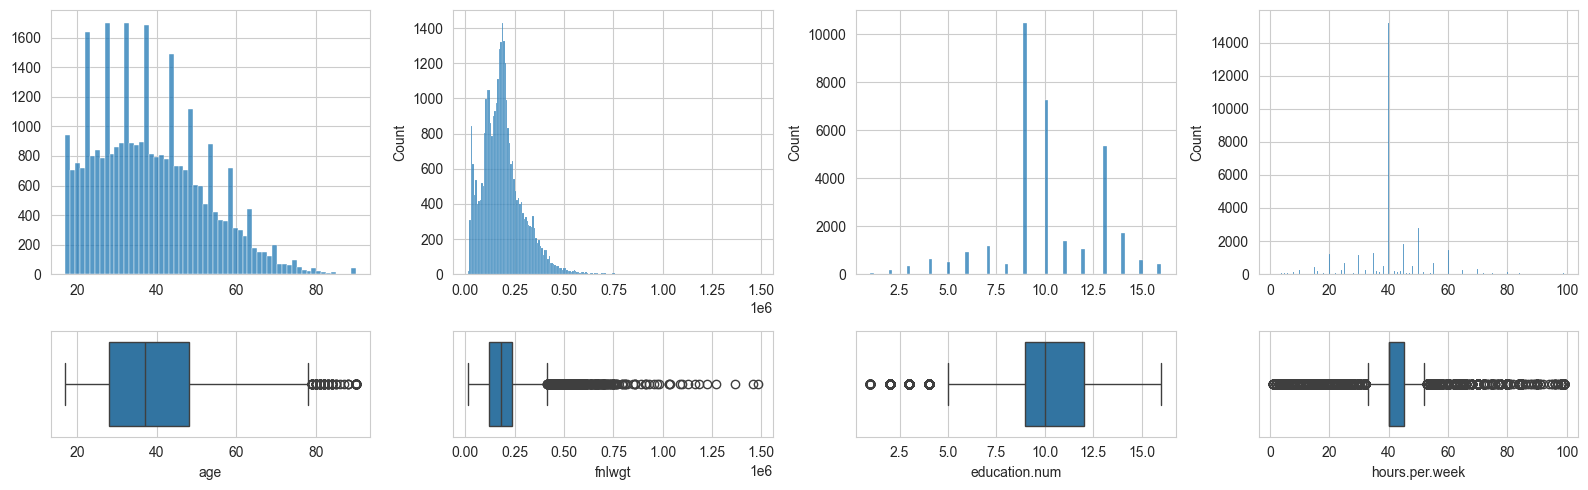

In [172]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="fnlwgt").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="fnlwgt")
sns.histplot(ax=axis[0, 2], data=df, x="education.num").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="education.num")
sns.histplot(ax=axis[0, 3], data=df, x="hours.per.week").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="hours.per.week")
plt.tight_layout()
plt.show()

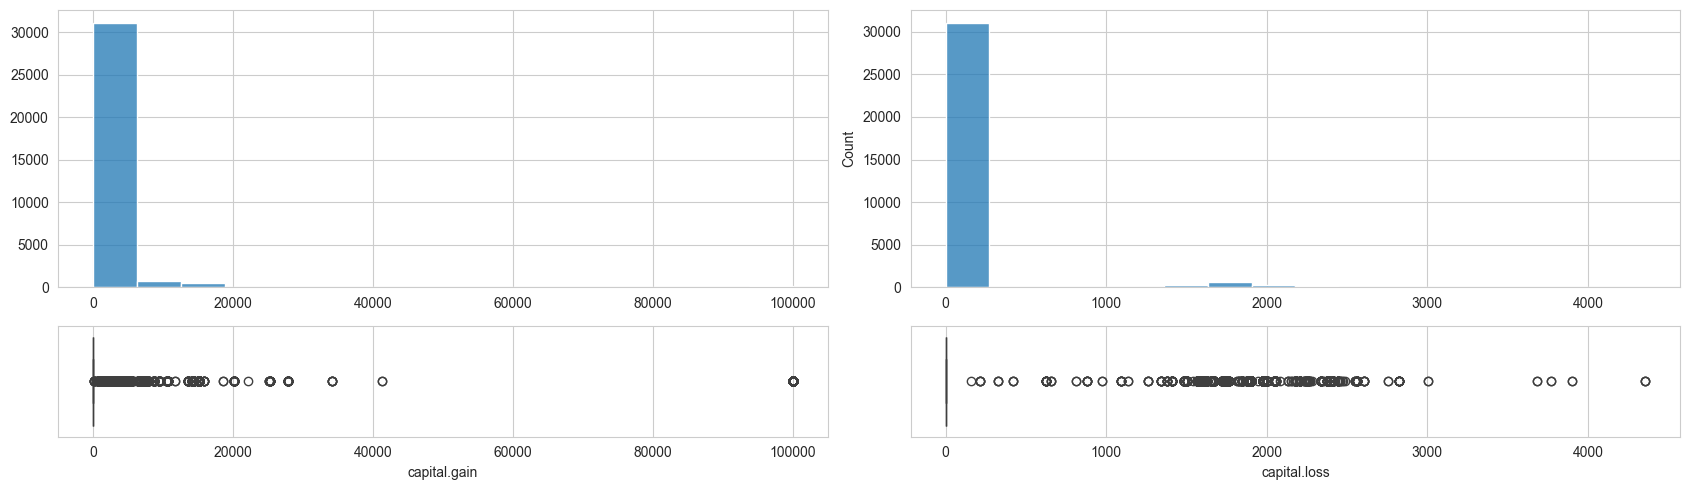

In [173]:
fig, axis = plt.subplots(2, 2, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="capital.gain").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="capital.gain")
sns.histplot(ax=axis[0, 1], data=df, x="capital.loss").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="capital.loss")


plt.tight_layout()
plt.show()

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

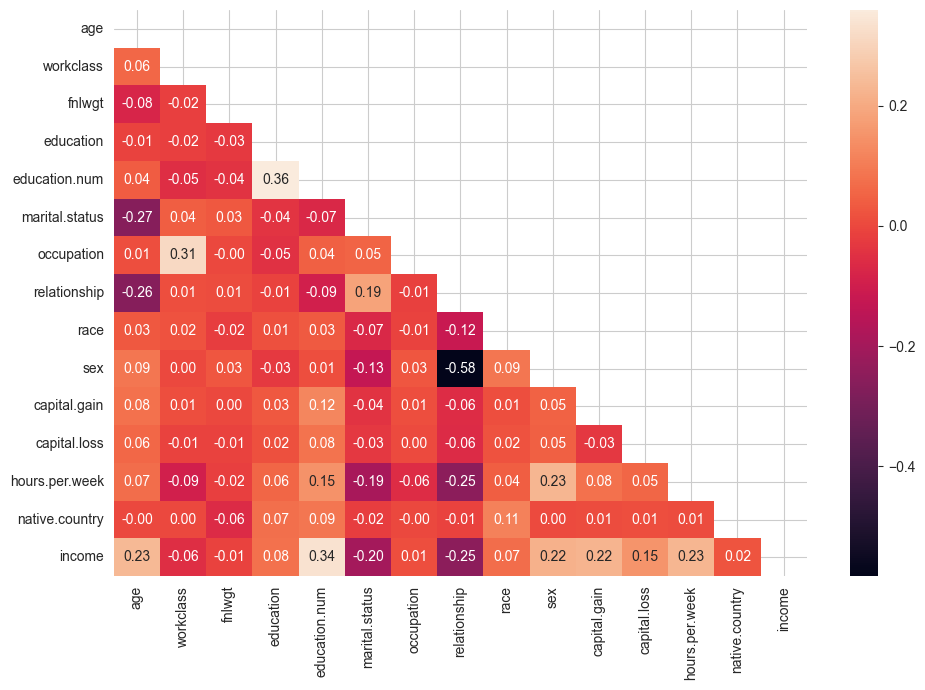

In [174]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:

#### Nos quedaremos con las variables más relacionadas con la variable income que utilizaremos como variable objetivo

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [175]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
workclass,32537.0,3.376587,1.582564,0.0,3.0,3.0,3.0,8.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education,32537.0,10.297507,3.870142,0.0,9.0,11.0,12.0,15.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
marital.status,32537.0,2.611427,1.506301,0.0,2.0,2.0,4.0,6.0
occupation,32537.0,6.422504,4.329257,0.0,3.0,6.0,10.0,14.0
relationship,32537.0,1.446538,1.607064,0.0,0.0,1.0,3.0,5.0
race,32537.0,3.665827,0.848847,0.0,4.0,4.0,4.0,4.0
sex,32537.0,0.669238,0.470495,0.0,0.0,1.0,1.0,1.0


#### Visualización

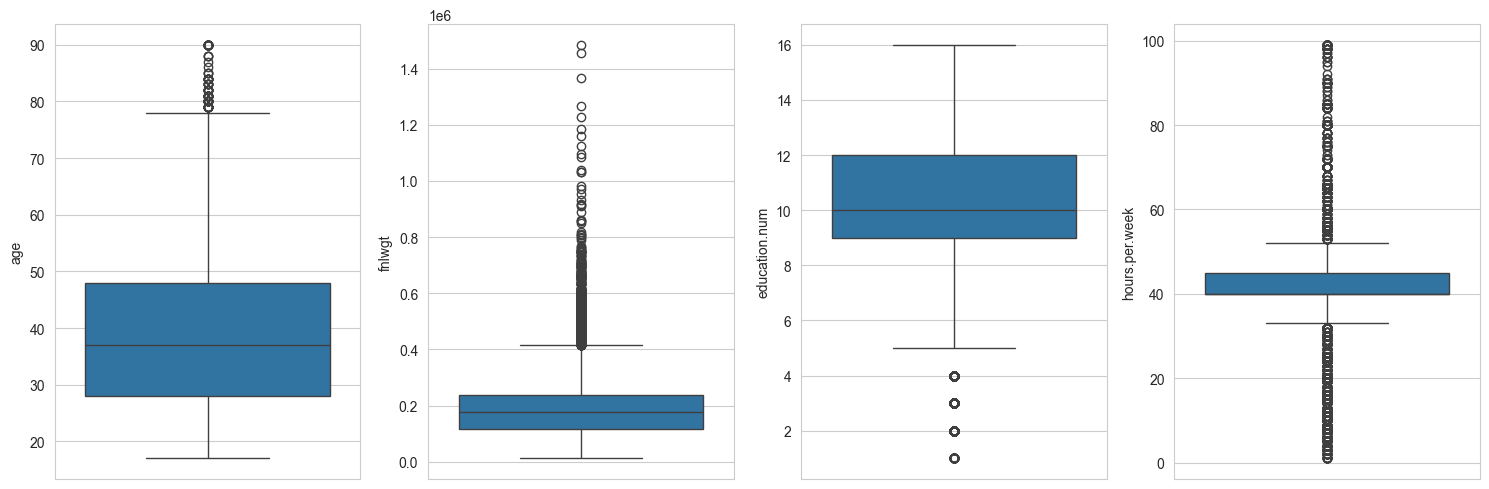

In [176]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="age")
sns.boxplot(ax=axis[1], data=df, y="fnlwgt")
sns.boxplot(ax=axis[2], data=df, y="education.num")
sns.boxplot(ax=axis[3], data=df, y="hours.per.week")
plt.tight_layout()
plt.show()

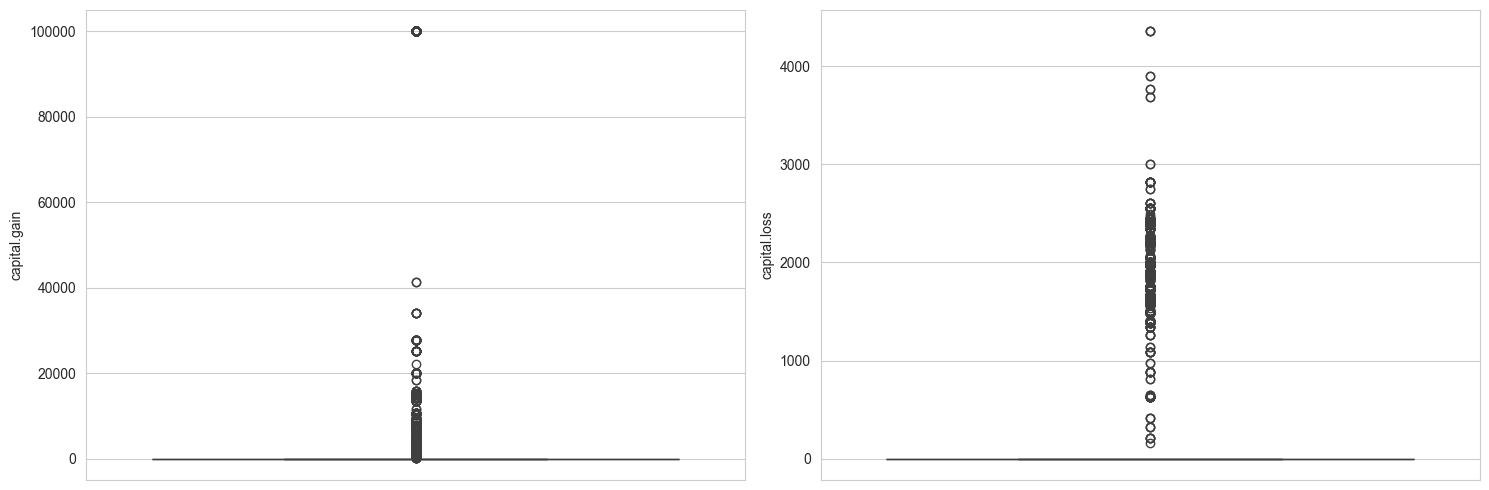

In [177]:
fig, axis = plt.subplots(1, 2, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="capital.gain")
sns.boxplot(ax=axis[1], data=df, y="capital.loss")
plt.tight_layout()
plt.show()

### Análisis de valores faltantes

In [178]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64

#### En este caso no existen valores nulos



In [181]:
corr_income

education.num     0.335272
relationship      0.250948
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
sex               0.215969
marital.status    0.199199
capital.loss      0.150501
education         0.079366
race              0.071847
workclass         0.055180
native.country    0.022957
occupation        0.010674
fnlwgt            0.009502
Name: income, dtype: float64

In [186]:
df_final = df[['education.num', 'relationship', 'age', 'hours.per.week', 'sex', 'marital.status', 'capital.gain', 'capital.loss', 'income']]
df_final

,education.num,relationship,age,hours.per.week,sex,marital.status,capital.gain,capital.loss,income
0,9,1,90,40,0,6,0,4356,0
1,9,1,82,18,0,6,0,4356,0
2,10,4,66,40,0,6,0,4356,0
3,4,4,54,40,0,0,0,3900,0
4,10,3,41,40,0,5,0,3900,0
...,...,...,...,...,...,...,...,...,...
32556,10,1,22,40,1,4,0,0,0
32557,12,5,27,38,0,2,0,0,0
32558,9,0,40,40,1,2,0,0,1
32559,9,4,58,40,0,6,0,0,0


## Split de datos (elegimos la variable quality como target)


In [ ]:
X = df.drop(['quality', 'label'], axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,7.7,0.600,0.06,2.0,0.079,19.0,41.0,0.99697,3.39,0.62,10.1
59,7.3,0.390,0.31,2.4,0.074,9.0,46.0,0.99620,3.41,0.54,9.4
375,11.5,0.540,0.71,4.4,0.124,6.0,15.0,0.99840,3.01,0.83,11.8
1371,7.5,0.580,0.56,3.1,0.153,5.0,14.0,0.99476,3.21,1.03,11.6
1469,7.3,0.980,0.05,2.1,0.061,20.0,49.0,0.99705,3.31,0.55,9.7
...,...,...,...,...,...,...,...,...,...,...,...
164,7.3,0.590,0.26,7.2,0.070,35.0,121.0,0.99810,3.37,0.49,9.4
393,8.4,0.665,0.61,2.0,0.112,13.0,95.0,0.99700,3.16,0.54,9.1
216,8.7,0.625,0.16,2.0,0.101,13.0,49.0,0.99620,3.14,0.57,11.0
1056,8.9,0.480,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1


## Scaling & Encoding

### Scaling

#### Usamos el método RobustScaler porque es mejor para un modelo de KN-neighbors con valores atípicos

#### Scaling X_train

In [ ]:
robust_scaler = RobustScaler() 
num_variables = X_train.columns.tolist()
robust_train_features = robust_scaler.fit_transform(X_train[num_variables])
X_train_scaled = pd.DataFrame(robust_train_features,
                              index=X_train.index,
                              columns=num_variables)
X_train_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,-0.095238,0.36,-0.606061,-0.285714,0.000000,0.357143,0.047619,0.075221,0.421053,0.000000,-0.0625
59,-0.285714,-0.48,0.151515,0.285714,-0.238095,-0.357143,0.166667,-0.265487,0.526316,-0.444444,-0.5000
375,1.714286,0.12,1.363636,3.142857,2.142857,-0.571429,-0.571429,0.707965,-1.578947,1.166667,1.0000
1371,-0.190476,0.28,0.909091,1.285714,3.523810,-0.642857,-0.595238,-0.902655,-0.526316,2.277778,0.8750
1469,-0.285714,1.88,-0.636364,-0.142857,-0.857143,0.428571,0.238095,0.110619,0.000000,-0.388889,-0.3125
...,...,...,...,...,...,...,...,...,...,...,...
164,-0.285714,0.32,0.000000,7.142857,-0.428571,1.500000,1.952381,0.575221,0.315789,-0.722222,-0.5000
393,0.238095,0.62,1.060606,-0.285714,1.571429,-0.071429,1.333333,0.088496,-0.789474,-0.444444,-0.6875
216,0.380952,0.46,-0.303030,-0.285714,1.047619,-0.071429,0.238095,-0.265487,-0.894737,-0.277778,0.5000
1056,0.476190,-0.12,0.818182,2.571429,1.047619,-0.785714,-0.690476,-0.415929,-0.526316,-0.166667,1.1875


#### Scaling X_test

In [ ]:

X_test_scaled = pd.DataFrame(robust_scaler.transform(X_test[num_variables]),
                               index=X_test.index,
                               columns=num_variables)
X_test_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
887,1.333333,0.04,0.363636,0.571429,-0.619048,1.071429,0.404762,-0.455752,-0.842105,0.944444,1.1875
717,-0.142857,-0.20,-0.454545,0.571429,0.000000,-0.142857,0.238095,0.000000,-0.526316,-0.277778,-0.1250
221,-0.238095,0.08,0.000000,-0.285714,1.047619,0.142857,0.785714,-0.486726,-0.842105,-0.277778,-0.5000
1218,0.142857,-0.44,0.151515,-0.428571,0.142857,-0.428571,-0.357143,-0.353982,-0.368421,0.388889,0.2500
1487,-0.904762,0.52,-0.636364,-0.428571,-0.619048,-0.357143,-0.523810,-0.814159,1.105263,0.888889,0.2500
...,...,...,...,...,...,...,...,...,...,...,...
1003,-0.523810,-0.60,0.181818,-0.571429,-0.571429,-0.714286,-0.738095,-1.769912,0.263158,-0.388889,1.6250
739,0.523810,0.72,-0.787879,0.285714,0.428571,0.357143,-0.023810,0.973451,0.210526,-0.111111,-0.5625
645,-0.047619,0.52,-0.484848,5.428571,1.714286,-0.642857,-0.666667,0.707965,0.315789,0.388889,-0.0625
1300,-1.285714,0.54,-0.787879,-0.071429,0.047619,0.071429,-0.261905,-1.044248,2.473684,-0.055556,1.4375


In [ ]:
X_train_scaled.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/xtrain-knn.csv", index=False)
X_test_scaled.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/xtest-knn.csv", index=False)
y_train.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/ytrain-knn.csv", index=False)
y_test.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/ytest-knn.csv", index=False)


### Guardado de scalers y encoders

In [ ]:
with open('../data/raw/winequality-robust-scaler.pkl', 'wb') as file:
    pickle.dump(robust_scaler, file)